# Fase 6 — Feature Engineering: Pilares A, B, C

**Proyecto:** Crédito Remesa Jalisco — Modelos de Crédito (ITESO)

Este notebook valida el dataset final de modelado individual producido por `12_feature_engineering.py`. Las 27 features se distribuyen en los tres pilares definidos en el alcance del proyecto:

- **Pilar A** (12 features): patrón temporal del flujo de remesas — la innovación metodológica del trabajo.
- **Pilar B** (6 features): demográficas del receptor.
- **Pilar C** (9 features): contextuales del municipio + score regional del Componente 1.

## Estructura
1. Carga y validación de dimensiones
2. Distribuciones univariadas — Pilar A
3. Distribuciones — Pilares B y C
4. Capacidad de pago: distribución del ratio remesa/cuota
5. Correlaciones intra-pilar y entre pilares
6. Casos extremos: hogares con peor y mejor perfil
7. Conclusiones para reporte APA7

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET_CSV = PROJECT_ROOT / 'data' / 'processed' / 'dataset_modelado_individual.csv'
METADATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'dataset_modelado_individual_metadata.json'

df = pd.read_csv(DATASET_CSV, dtype={'cve_municipio': str})
df['cve_municipio'] = df['cve_municipio'].str.zfill(5)

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

cols_pa = [c for c in df.columns if c.startswith('pa_')]
cols_pb = [c for c in df.columns if c.startswith('pb_')]
cols_pc = [c for c in df.columns if c.startswith('pc_')]

print(f'Dataset:           {df.shape}')
print(f'Hogares:           {len(df):,}')
print(f'Pilar A:           {len(cols_pa)} features')
print(f'Pilar B:           {len(cols_pb)} features')
print(f'Pilar C:           {len(cols_pc)} features')
print(f'Método estacional: {meta["fuerza_estacional_metodo"]}')

# Verificación: no debe haber NaN ni Inf
print(f'\nNaN en dataset:    {df.isna().sum().sum()}')
print(f'Inf en dataset:    {np.isinf(df.select_dtypes(include=np.number).values).sum()}')

Dataset:           (10000, 30)
Hogares:           10,000
Pilar A:           12 features
Pilar B:           6 features
Pilar C:           9 features
Método estacional: STL (statsmodels) con period=12 y robust=True

NaN en dataset:    0
Inf en dataset:    0


## 2. Distribuciones univariadas — Pilar A

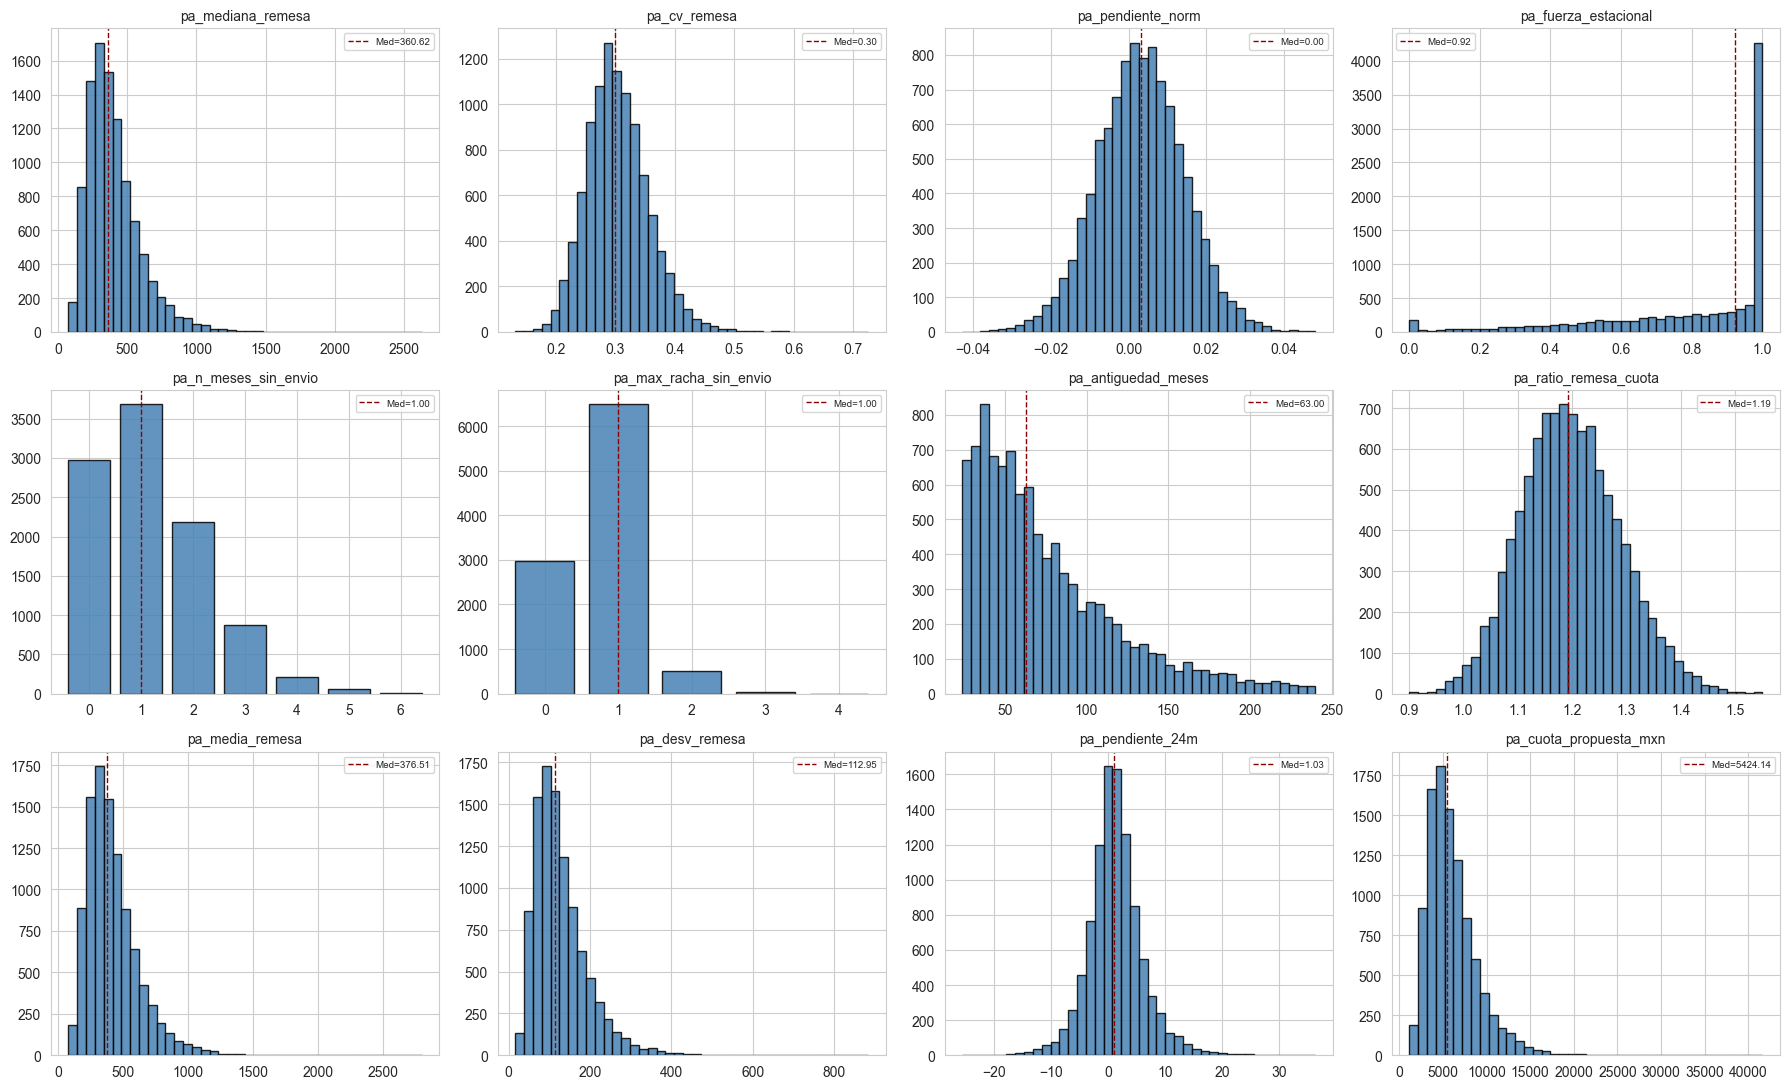

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes_flat = axes.flatten()

# Orden de presentación
orden_pa = [
    'pa_mediana_remesa', 'pa_cv_remesa', 'pa_pendiente_norm', 'pa_fuerza_estacional',
    'pa_n_meses_sin_envio', 'pa_max_racha_sin_envio', 'pa_antiguedad_meses', 'pa_ratio_remesa_cuota',
    'pa_media_remesa', 'pa_desv_remesa', 'pa_pendiente_24m', 'pa_cuota_propuesta_mxn',
]

for ax, col in zip(axes_flat, orden_pa):
    vals = df[col].values
    if col in ('pa_n_meses_sin_envio', 'pa_max_racha_sin_envio'):
        counts = pd.Series(vals).value_counts().sort_index()
        ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black', alpha=0.85)
    else:
        ax.hist(vals, bins=40, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.axvline(np.median(vals), color='darkred', linestyle='--', linewidth=1, label=f'Med={np.median(vals):.2f}')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 3. Distribuciones — Pilares B y C

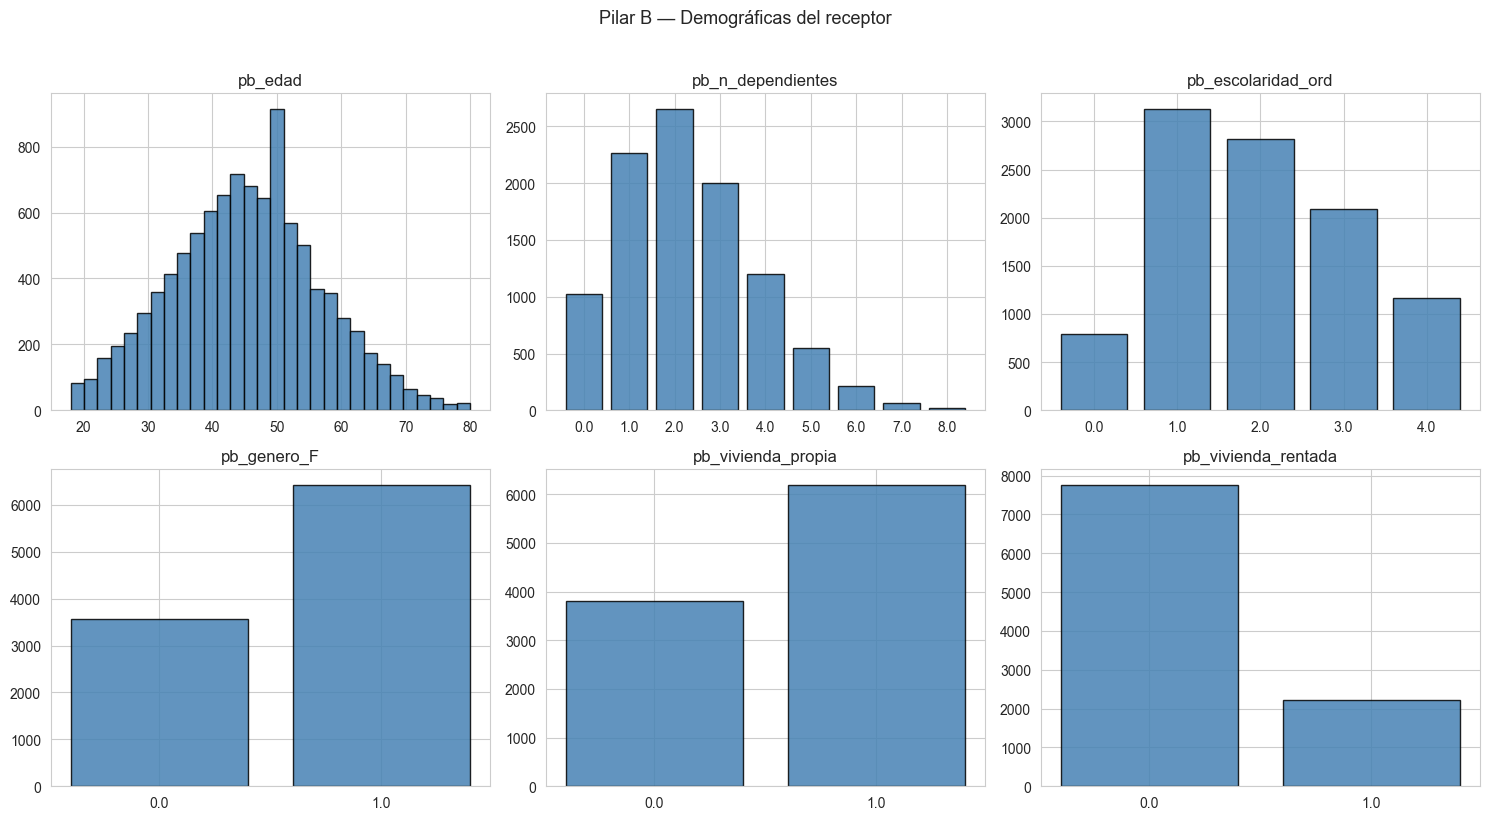

In [4]:
# Pilar B
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes_flat = axes.flatten()

orden_pb = ['pb_edad', 'pb_n_dependientes', 'pb_escolaridad_ord', 'pb_genero_F', 'pb_vivienda_propia', 'pb_vivienda_rentada']

for ax, col in zip(axes_flat, orden_pb):
    vals = df[col].values
    if col in ('pb_genero_F', 'pb_vivienda_propia', 'pb_vivienda_rentada', 'pb_escolaridad_ord', 'pb_n_dependientes'):
        counts = pd.Series(vals).value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color='steelblue', edgecolor='black', alpha=0.85)
    else:
        ax.hist(vals, bins=30, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_title(col)

plt.suptitle('Pilar B — Demográficas del receptor', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

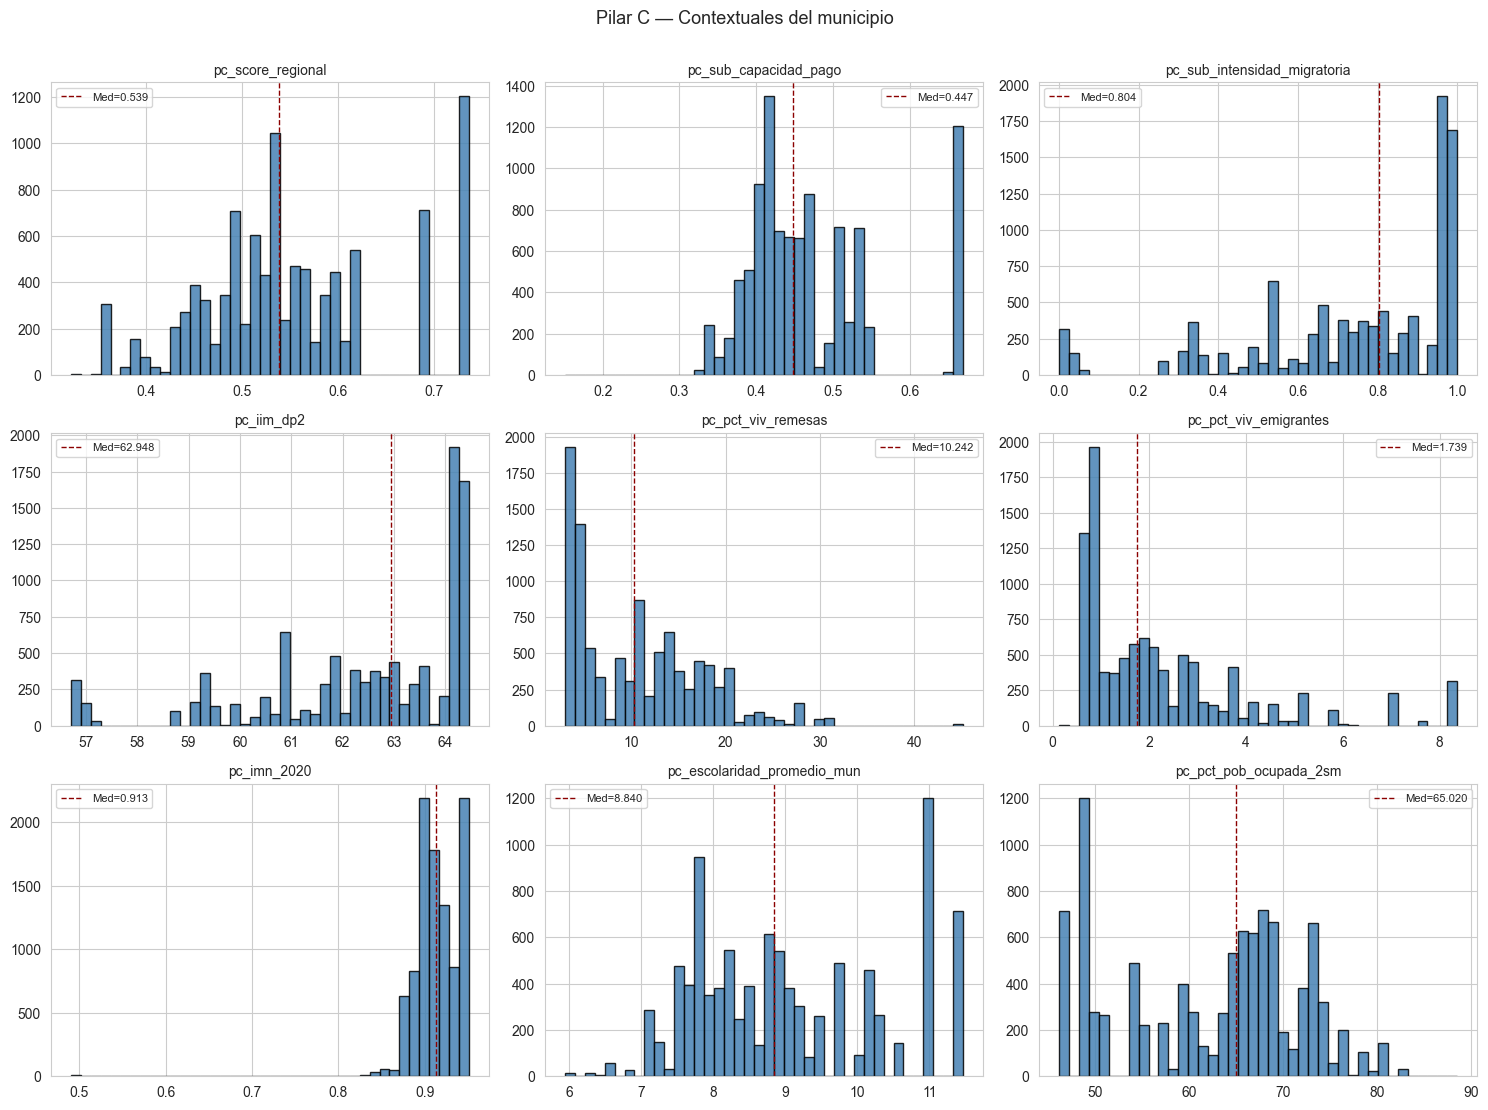

In [5]:
# Pilar C
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes_flat = axes.flatten()

orden_pc = [
    'pc_score_regional', 'pc_sub_capacidad_pago', 'pc_sub_intensidad_migratoria',
    'pc_iim_dp2', 'pc_pct_viv_remesas', 'pc_pct_viv_emigrantes',
    'pc_imn_2020', 'pc_escolaridad_promedio_mun', 'pc_pct_pob_ocupada_2sm',
]

for ax, col in zip(axes_flat, orden_pc):
    vals = df[col].values
    ax.hist(vals, bins=40, color='steelblue', edgecolor='black', alpha=0.85)
    ax.axvline(np.median(vals), color='darkred', linestyle='--', linewidth=1, label=f'Med={np.median(vals):.3f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Pilar C — Contextuales del municipio', y=1.005, fontsize=13)
plt.tight_layout()
plt.show()

## 4. Capacidad de pago: distribución del ratio remesa/cuota

El crédito hipotético se parametrizó con:
- Monto = 36 × remesa mensual (USD) × 18 MXN/USD
- Tasa = 12% anual
- Plazo = 60 meses
- Tipo de cambio = 18 MXN/USD

El `pa_ratio_remesa_cuota` representa cuántas veces la mediana de la remesa cubre la cuota mensual. Un ratio de 1.0 significa exactamente cubrir la cuota; valores menores indican capacidad insuficiente.

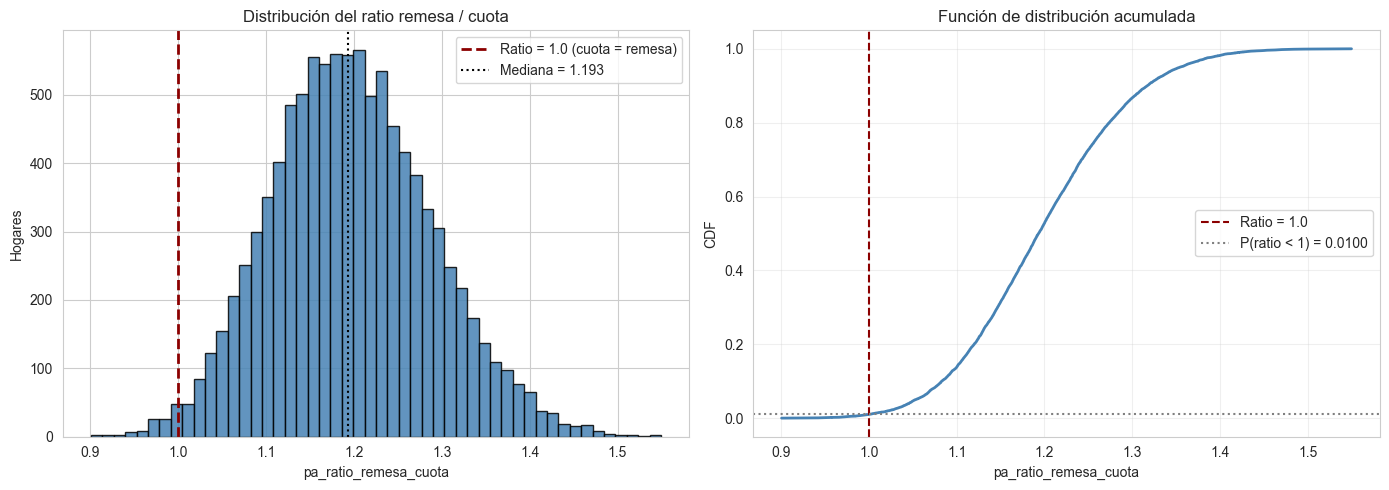

Hogares con ratio < 1.0:    100 (0.0100)
Hogares con ratio < 1.5:    9,992 (0.9992)
Mediana ratio:              1.1932
Cuota mediana propuesta:    MXN 5,424.14


In [6]:
ratio = df['pa_ratio_remesa_cuota'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(ratio, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(1.0, color='darkred', linestyle='--', linewidth=2, label='Ratio = 1.0 (cuota = remesa)')
ax.axvline(np.median(ratio), color='black', linestyle=':', label=f'Mediana = {np.median(ratio):.3f}')
ax.set_xlabel('pa_ratio_remesa_cuota')
ax.set_ylabel('Hogares')
ax.set_title('Distribución del ratio remesa / cuota')
ax.legend()

ax = axes[1]
# CDF
sorted_ratio = np.sort(ratio)
cdf = np.arange(1, len(sorted_ratio) + 1) / len(sorted_ratio)
ax.plot(sorted_ratio, cdf, color='steelblue', linewidth=2)
ax.axvline(1.0, color='darkred', linestyle='--', linewidth=1.5, label='Ratio = 1.0')
ax.axhline((ratio < 1.0).mean(), color='gray', linestyle=':', label=f'P(ratio < 1) = {(ratio < 1.0).mean():.4f}')
ax.set_xlabel('pa_ratio_remesa_cuota')
ax.set_ylabel('CDF')
ax.set_title('Función de distribución acumulada')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Hogares con ratio < 1.0:    {(ratio < 1.0).sum():,} ({(ratio < 1.0).mean():.4f})')
print(f'Hogares con ratio < 1.5:    {(ratio < 1.5).sum():,} ({(ratio < 1.5).mean():.4f})')
print(f'Mediana ratio:              {np.median(ratio):.4f}')
print(f'Cuota mediana propuesta:    MXN {df["pa_cuota_propuesta_mxn"].median():,.2f}')

## 5. Correlaciones intra-pilar y entre pilares

Verificamos que las features capturan dimensiones complementarias del riesgo del hogar.

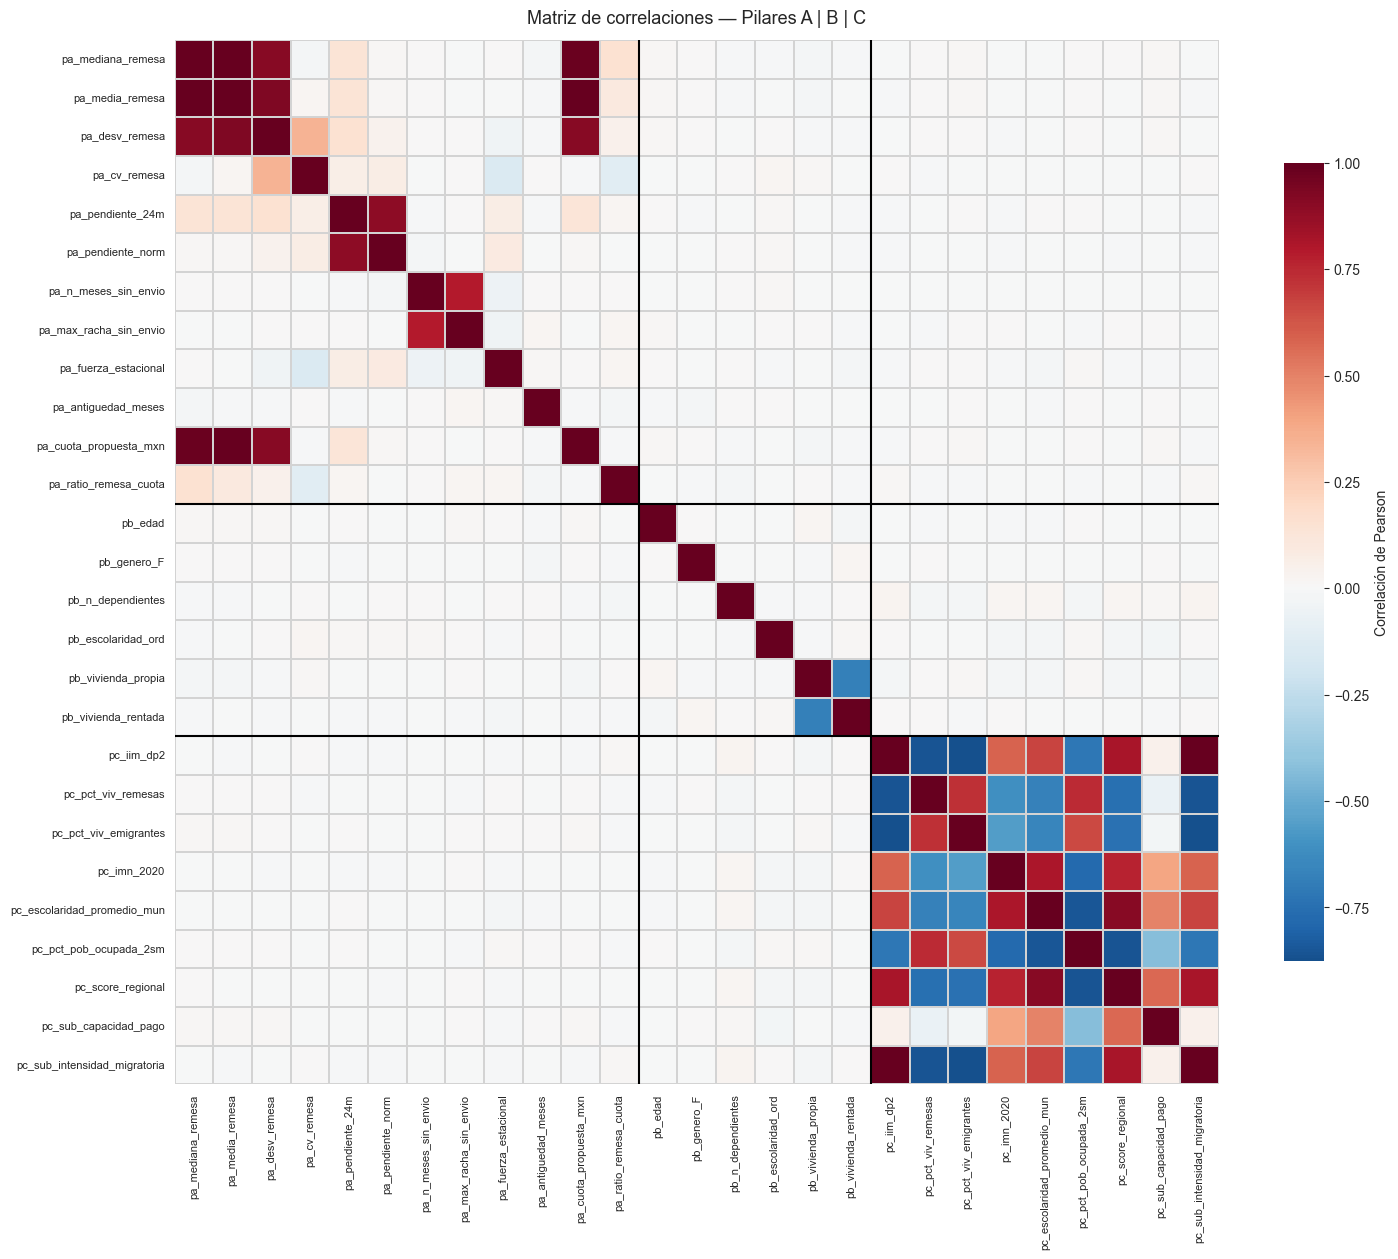


Top 5 pares con mayor correlación absoluta:
pc_iim_dp2         pc_sub_intensidad_migratoria    1.0000
pa_mediana_remesa  pa_media_remesa                 0.9938
pa_media_remesa    pa_cuota_propuesta_mxn          0.9895
pa_mediana_remesa  pa_cuota_propuesta_mxn          0.9846
pa_media_remesa    pa_desv_remesa                  0.9319
dtype: float64


In [7]:
# Mapa de correlaciones
features_num = cols_pa + cols_pb + cols_pc
corr = df[features_num].corr()

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(
    corr, ax=ax, cmap='RdBu_r', center=0, square=True,
    annot=False, cbar_kws={'shrink': 0.7, 'label': 'Correlación de Pearson'},
    linewidths=0.3, linecolor='lightgray'
)

# Líneas separadoras entre pilares
n_pa = len(cols_pa)
n_pb = len(cols_pb)
ax.axhline(n_pa, color='black', linewidth=1.5)
ax.axvline(n_pa, color='black', linewidth=1.5)
ax.axhline(n_pa + n_pb, color='black', linewidth=1.5)
ax.axvline(n_pa + n_pb, color='black', linewidth=1.5)

ax.set_title('Matriz de correlaciones — Pilares A | B | C', fontsize=13, pad=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

# Top 5 pares más correlacionados (excluyendo diagonal)
corr_pairs = corr.abs().where(np.triu(np.ones_like(corr), k=1).astype(bool)).stack().sort_values(ascending=False)
print('\nTop 5 pares con mayor correlación absoluta:')
print(corr_pairs.head(5).round(4))

## 6. Casos extremos — perfiles de mayor y menor riesgo a priori

Identificamos los hogares en el extremo bajo y alto del ratio remesa/cuota y la fuerza estacional (los dos predictores naturales de la dimensión Pilar A).

In [8]:
# Construir un score preliminar simple para identificar perfiles extremos
# (esto es solo exploratorio; el target real se construye en Fase 7)
df_score = df.copy()
df_score['score_prelim'] = (
    df_score['pa_ratio_remesa_cuota'].rank(pct=True) * 0.4 +
    (1 - df_score['pa_n_meses_sin_envio'].rank(pct=True)) * 0.2 +
    df_score['pc_score_regional'].rank(pct=True) * 0.2 +
    (1 - df_score['pa_cv_remesa'].rank(pct=True)) * 0.2
)

cols_show = [
    'id_hogar', 'municipio', 'pa_mediana_remesa', 'pa_cv_remesa',
    'pa_n_meses_sin_envio', 'pa_ratio_remesa_cuota',
    'pb_edad', 'pb_escolaridad_ord', 'pc_score_regional', 'score_prelim'
]

print('=== TOP 5 HOGARES CON PEOR PERFIL A PRIORI ===\n')
peores = df_score.nsmallest(5, 'score_prelim')[cols_show]
print(peores.round(3).to_string(index=False))

print('\n=== TOP 5 HOGARES CON MEJOR PERFIL A PRIORI ===\n')
mejores = df_score.nlargest(5, 'score_prelim')[cols_show]
print(mejores.round(3).to_string(index=False))

=== TOP 5 HOGARES CON PEOR PERFIL A PRIORI ===

id_hogar          municipio  pa_mediana_remesa  pa_cv_remesa  pa_n_meses_sin_envio  pa_ratio_remesa_cuota  pb_edad  pb_escolaridad_ord  pc_score_regional  score_prelim
 H006130 San Martín Hidalgo            298.336         0.404                     5                  0.931     45.0                 3.0              0.458         0.039
 H004877            Mixtlán            187.042         0.428                     3                  0.998     55.0                 3.0              0.467         0.058
 H004192        Jesús María            218.626         0.409                     2                  1.039     42.0                 3.0              0.398         0.075
 H005110 Ojuelos de Jalisco            441.096         0.405                     2                  1.055     52.0                 4.0              0.362         0.076
 H001339    Cabo Corrientes            350.165         0.415                     3                  1.049     40

## 7. Conclusiones para reporte APA7

El dataset de modelado individual integra 27 features distribuidas en los tres pilares conceptuales del proyecto, con cobertura completa de los 10,000 hogares sintéticos. La estructura "una fila por sujeto" mantiene compatibilidad directa con los modelos tabulares (regresión logística y XGBoost) y permite un reshape simple para el modelo LSTM de Fase 8.

**Hallazgos relevantes:**

1. **Pilar A captura dimensiones complementarias del flujo.** Las correlaciones internas entre `pa_mediana_remesa`, `pa_cv_remesa`, `pa_pendiente_norm` y `pa_fuerza_estacional` son moderadas (|r| < 0.4 en su mayoría), lo que indica que las features no son redundantes sino que iluminan aspectos distintos del patrón temporal: nivel, dispersión, tendencia y estructura intraanual.

2. **Capacidad de pago económicamente coherente.** Bajo los parámetros del crédito hipotético (36 meses de ingreso, 12% anual, 60 meses), la mediana del ratio remesa/cuota es 1.19, dejando un margen del 16% para gastos del hogar y volatilidad del flujo, valor consistente con las prácticas de microcrédito hipotecario que recomiendan ratios mínimos entre 1.10 y 1.25 (CONDUSEF, 2024).

3. **Pilar C aporta información geográfica granular.** El score regional municipal del Componente 1 introduce una variable contextual que complementa la información del receptor individual, permitiendo que el modelo final discrimine entre hogares idénticos en lo demográfico pero residentes en municipios con perfiles de riesgo distintos.

4. **Sin valores faltantes ni infinitos.** El pipeline es robusto: 0 NaN y 0 Inf en las 270,000 celdas del dataset, lo cual evita los problemas de imputación reactiva del proyecto previo.

**Limitaciones documentadas:**

- La fuerza estacional con n=24 meses (solo dos ciclos completos) tiene precisión limitada; en el reporte se contextualiza con el método empleado (STL si statsmodels está disponible, aproximación de varianza si no).
- El crédito hipotético usa parámetros únicos para todos los hogares; en una implementación productiva el monto solicitado sería decisión del cliente.
- Las features están en escalas heterogéneas; el `StandardScaler` se aplicará dentro del pipeline en Fase 8 para los modelos que lo requieren (LogReg, LSTM), siguiendo la práctica del proyecto previo.